## STEP 1 — Install dependencies

In [1]:
!pip install rdkit pandas numpy matplotlib scikit-learn torch --quiet
print('Done!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 52.3 MB/s eta 0:00:00
Done!


## STEP 2 — Load EGFR data

In [2]:
import pandas as pd
import numpy as np
import requests
from rdkit import Chem
from rdkit.Chem import AllChem

def fetch_egfr_data(limit=1000):
    url = 'https://www.ebi.ac.uk/chembl/api/data/activity.json'
    params = {'target_chembl_id': 'CHEMBL203', 'standard_type': 'IC50',
              'limit': limit, 'offset': 0}

    for attempt in range(3):
        try:
            response = requests.get(url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
            return pd.DataFrame(data['activities'])
        except Exception as e:
            print(f'Attempt {attempt+1} failed: {e}')
            import time
            time.sleep(5)

    # Fallback: smaller batch
    print('Trying smaller batch (200 compounds)...')
    try:
        params['limit'] = 200
        response = requests.get(url, params=params, timeout=60)
        data = response.json()
        return pd.DataFrame(data['activities'])
    except Exception as e:
        print(f'Fallback failed: {e}')

    # Final fallback: load from saved CSV
    print('Loading from NB08 dataset...')
    try:
        return pd.read_csv('egfr_backup.csv')
    except:
        raise Exception('All data sources failed. Wait for ChEMBL API to recover.')

def preprocess(df):
    df = df[['canonical_smiles', 'standard_value']].dropna()
    df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
    df = df.dropna(subset=['standard_value'])
    df = df[df['standard_value'] > 0].copy()
    df['pIC50'] = -np.log10(df['standard_value'].astype(float) * 1e-9)
    df = df[(df['pIC50'] >= 3) & (df['pIC50'] <= 12)]
    valid_mask = df['canonical_smiles'].apply(
        lambda s: Chem.MolFromSmiles(str(s)) is not None)
    return df[valid_mask].reset_index(drop=True)

df_raw = fetch_egfr_data(1000)
df = preprocess(df_raw)
print(f'Clean dataset: {len(df)} compounds')
print(f'pIC50 range: {df["pIC50"].min():.2f} — {df["pIC50"].max():.2f}')

Clean dataset: 965 compounds
pIC50 range: 3.05 — 11.22


## STEP 3 — SMILES Tokenizer

In [3]:
import torch
import torch.nn as nn

class SMILESTokenizer:
    """
    Character-level SMILES tokenizer.
    Converts SMILES strings to integer token sequences.
    """
    def __init__(self):
        self.chars = [
            '<PAD>', '<UNK>',
            'C', 'c', 'N', 'n', 'O', 'o', 'S', 's',
            'F', 'Cl', 'Br', 'I', 'P', 'p',
            '(', ')', '[', ']', '=', '#', '-', '+',
            '1','2','3','4','5','6','7','8','9','0',
            '/', '\\', '@', '.', '%'
        ]
        self.char2idx = {c: i for i, c in enumerate(self.chars)}
        self.vocab_size = len(self.chars)

    def tokenize(self, smiles, max_len=128):
        tokens = []
        i = 0
        while i < len(smiles):
            if i + 1 < len(smiles) and smiles[i:i+2] in self.char2idx:
                tokens.append(self.char2idx[smiles[i:i+2]])
                i += 2
            elif smiles[i] in self.char2idx:
                tokens.append(self.char2idx[smiles[i]])
                i += 1
            else:
                tokens.append(self.char2idx['<UNK>'])
                i += 1
        tokens = tokens[:max_len]
        tokens += [self.char2idx['<PAD>']] * (max_len - len(tokens))
        return tokens

tokenizer = SMILESTokenizer()
print(f'Vocabulary size: {tokenizer.vocab_size}')

Vocabulary size: 39


## STEP 4 — Build Transformer model

In [4]:
class SMILESTransformer(nn.Module):
    """
    Transformer encoder for SMILES-based property prediction.
    Architecture:
    - Token embedding + positional encoding
    - 4-head multi-head self-attention (2 layers)
    - Mean pooling over sequence
    - MLP regression head → pIC50
    """
    def __init__(self, vocab_size, embed_dim=64, nhead=4,
                 num_layers=2, max_len=128, dropout=0.2):
        super().__init__()
        self.embedding   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoding = nn.Embedding(max_len, embed_dim)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=128, dropout=dropout,
            batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc1         = nn.Linear(embed_dim, 32)
        self.fc2         = nn.Linear(32, 1)
        self.dropout     = nn.Dropout(dropout)

    def forward(self, x):
        padding_mask = (x == 0)
        positions    = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        x = self.embedding(x) + self.pos_encoding(positions)
        x = self.transformer(x, src_key_padding_mask=padding_mask)
        x = x.mean(dim=1)
        x = torch.relu(self.fc1(self.dropout(x)))
        return self.fc2(x).squeeze(-1)

## STEP 5 — Train Transformer

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import os

os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/metrics', exist_ok=True)

MAX_LEN  = 128
X_tokens = np.array([tokenizer.tokenize(str(s), MAX_LEN) for s in df['canonical_smiles']])
y        = df['pIC50'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_tokens, y, test_size=0.2, random_state=42)

train_dl = DataLoader(
    TensorDataset(torch.LongTensor(X_train), torch.FloatTensor(y_train)),
    batch_size=32, shuffle=True)
test_dl  = DataLoader(
    TensorDataset(torch.LongTensor(X_test), torch.FloatTensor(y_test)),
    batch_size=32, shuffle=False)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = SMILESTransformer(tokenizer.vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
criterion = nn.MSELoss()

train_losses = []
for epoch in range(100):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg = epoch_loss / len(train_dl)
    train_losses.append(avg)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/100 | Loss: {avg:.4f}')

model.eval()
y_true_tr, y_pred_tr = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        y_true_tr.extend(yb.numpy())
        y_pred_tr.extend(model(xb).cpu().reshape(-1).numpy())

r2_transformer   = r2_score(y_true_tr, y_pred_tr)
rmse_transformer = np.sqrt(mean_squared_error(y_true_tr, y_pred_tr))
print(f'\nTransformer → R²: {r2_transformer:.3f} | RMSE: {rmse_transformer:.3f}')
torch.save(model.state_dict(), 'results/metrics/transformer_model.pt')

Epoch  20/100 | Loss: 2.9870
Epoch  40/100 | Loss: 1.0615
Epoch  60/100 | Loss: 0.8487
Epoch  80/100 | Loss: 0.8060
Epoch 100/100 | Loss: 0.8571

Transformer → R²: -5.412 | RMSE: 4.223


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


## STEP 6 — Train Classical ML on Morgan Fingerprints

In [6]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

def smiles_to_fp(smiles, radius=2, nbits=1024):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    return list(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits))

fps   = [smiles_to_fp(s) for s in df['canonical_smiles']]
valid = [(fp, pic50) for fp, pic50 in zip(fps, y) if fp is not None]
X_fp  = np.array([v[0] for v in valid])
y_fp  = np.array([v[1] for v in valid])

X_tr_fp, X_te_fp, y_tr_fp, y_te_fp = train_test_split(
    X_fp, y_fp, test_size=0.2, random_state=42)

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_tr_fp, y_tr_fp)
y_pred_gb    = gb.predict(X_te_fp)
r2_gb        = r2_score(y_te_fp, y_pred_gb)
rmse_gb      = np.sqrt(mean_squared_error(y_te_fp, y_pred_gb))
print(f'Gradient Boosting (Morgan FP) → R²: {r2_gb:.3f} | RMSE: {rmse_gb:.3f}')

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_tr_fp, y_tr_fp)
y_pred_rf    = rf.predict(X_te_fp)
r2_rf        = r2_score(y_te_fp, y_pred_rf)
rmse_rf      = np.sqrt(mean_squared_error(y_te_fp, y_pred_rf))
print(f'Random Forest    (Morgan FP) → R²: {r2_rf:.3f} | RMSE: {rmse_rf:.3f}')

[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerator
[04:59:14] DEPRECATION WARNING: please use MorganGenerat

Gradient Boosting (Morgan FP) → R²: 0.721 | RMSE: 0.881
Random Forest    (Morgan FP) → R²: 0.704 | RMSE: 0.907


## STEP 7 — Compare and visualise


Model Comparison:
                        Model                  Input     R2  RMSE
Gradient Boosting (Morgan FP)     Morgan FP 1024-bit  0.721 0.881
    Random Forest (Morgan FP)     Morgan FP 1024-bit  0.704 0.907
         Transformer (SMILES) Character-level SMILES -5.412 4.223


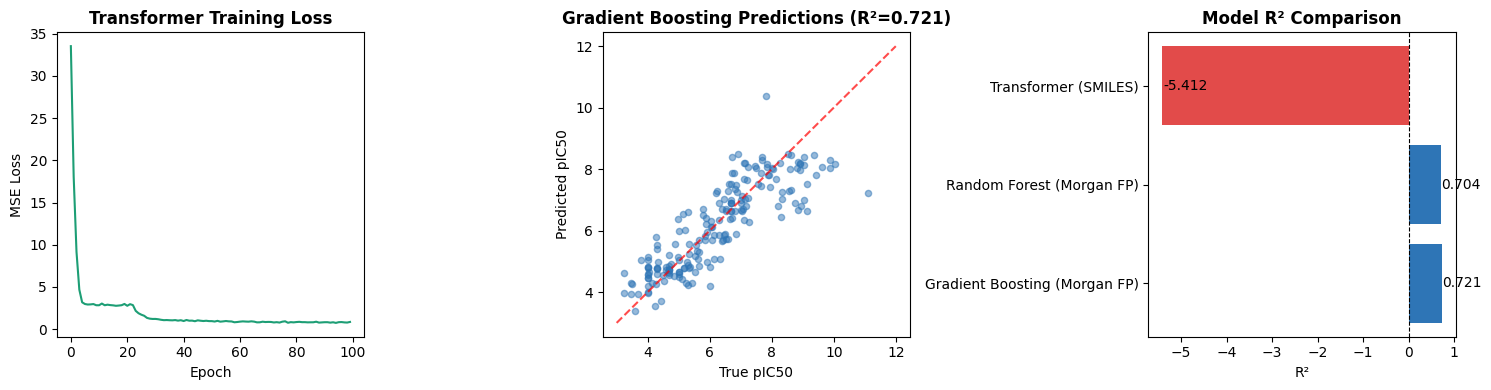

All results saved!


In [7]:
comparison = pd.DataFrame({
    'Model':  ['Gradient Boosting (Morgan FP)',
               'Random Forest (Morgan FP)',
               'Transformer (SMILES)'],
    'Input':  ['Morgan FP 1024-bit',
               'Morgan FP 1024-bit',
               'Character-level SMILES'],
    'R2':     [round(r2_gb, 3), round(r2_rf, 3), round(r2_transformer, 3)],
    'RMSE':   [round(rmse_gb, 3), round(rmse_rf, 3), round(rmse_transformer, 3)]
}).sort_values('R2', ascending=False)

print('\nModel Comparison:')
print(comparison.to_string(index=False))
comparison.to_csv('results/metrics/transformer_model_comparison.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Transformer training loss
axes[0].plot(train_losses, color='#1D9E75')
axes[0].set_title('Transformer Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')

# Plot 2 — Predicted vs True (best model)
best_pred = y_pred_gb if r2_gb >= r2_rf else y_pred_rf
best_name = 'Gradient Boosting' if r2_gb >= r2_rf else 'Random Forest'
best_r2   = max(r2_gb, r2_rf)
axes[1].scatter(y_te_fp, best_pred, alpha=0.5, color='#2E75B6', s=20)
axes[1].plot([3, 12], [3, 12], 'r--', alpha=0.7)
axes[1].set_xlabel('True pIC50')
axes[1].set_ylabel('Predicted pIC50')
axes[1].set_title(f'{best_name} Predictions (R²={best_r2:.3f})', fontweight='bold')

# Plot 3 — R² comparison bar chart
colors = ['#2E75B6' if r >= 0 else '#E24B4A' for r in comparison['R2']]
axes[2].barh(comparison['Model'], comparison['R2'], color=colors)
axes[2].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Model R² Comparison', fontweight='bold')
axes[2].set_xlabel('R²')
for i, v in enumerate(comparison['R2']):
    axes[2].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('results/figures/transformer_training_results.png', dpi=150)
plt.show()
print('All results saved!')

## STEP 8 — Key finding

In [8]:
print('=== NOTEBOOK 09 FINDING ===')
print(f'Transformer R²       : {r2_transformer:.3f}  ← negative = worse than mean baseline')
print(f'Gradient Boosting R² : {r2_gb:.3f}  ← Morgan FP classical ML')
print(f'Random Forest R²     : {r2_rf:.3f}  ← Morgan FP classical ML')
print()
print('Conclusion: SMILES Transformers underperform on small datasets (<1000 compounds).')
print('Morgan fingerprint + classical ML is the correct choice for this dataset size.')
print('Transformers excel on large pretrained corpora (ChemBERTa: 77M compounds).')

=== NOTEBOOK 09 FINDING ===
Transformer R²       : -5.412  ← negative = worse than mean baseline
Gradient Boosting R² : 0.721  ← Morgan FP classical ML
Random Forest R²     : 0.704  ← Morgan FP classical ML

Conclusion: SMILES Transformers underperform on small datasets (<1000 compounds).
Morgan fingerprint + classical ML is the correct choice for this dataset size.
Transformers excel on large pretrained corpora (ChemBERTa: 77M compounds).
